# Analyse Exploratoire

### Import des modules

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno # librairie pour identifier les données manquantes

: 

In [47]:
pd.set_option('display.max_columns', None)  # Affiche toutes les colonnes

pd.set_option('display.max_rows', None) # Affiche toutes les lignes

### Analyse Exploratoire

In [48]:
building_consumption = pd.read_csv('data/2016_Building_Energy_Benchmarking.csv')

In [49]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head(1)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.6122,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.5,189.0,7226362.5,7456910.0,2003882.0,1156514.25,3946027.0,12764.5293,1276453.0,False,NaN,Compliant,NaN,249.98,2.83


Types des colonnes :
OSEBuildingID                        int64
DataYear                             int64
BuildingType                        object
PrimaryPropertyType                 object
PropertyName                        object
Address                             object
City                                object
State                               object
ZipCode                            float64
TaxParcelIdentificationNumber       object
CouncilDistrictCode                  int64
Neighborhood                        object
Latitude                           float64
Longitude                          float64
YearBuilt                            int64
NumberofBuildings                  float64
NumberofFloors                       int64
PropertyGFATotal                     int64
PropertyGFAParking                   int64
PropertyGFABuilding(s)               int64
ListOfAllPropertyUseTypes           object
LargestPropertyUseType              object
LargestPropertyUseTypeGFA        

<Axes: >

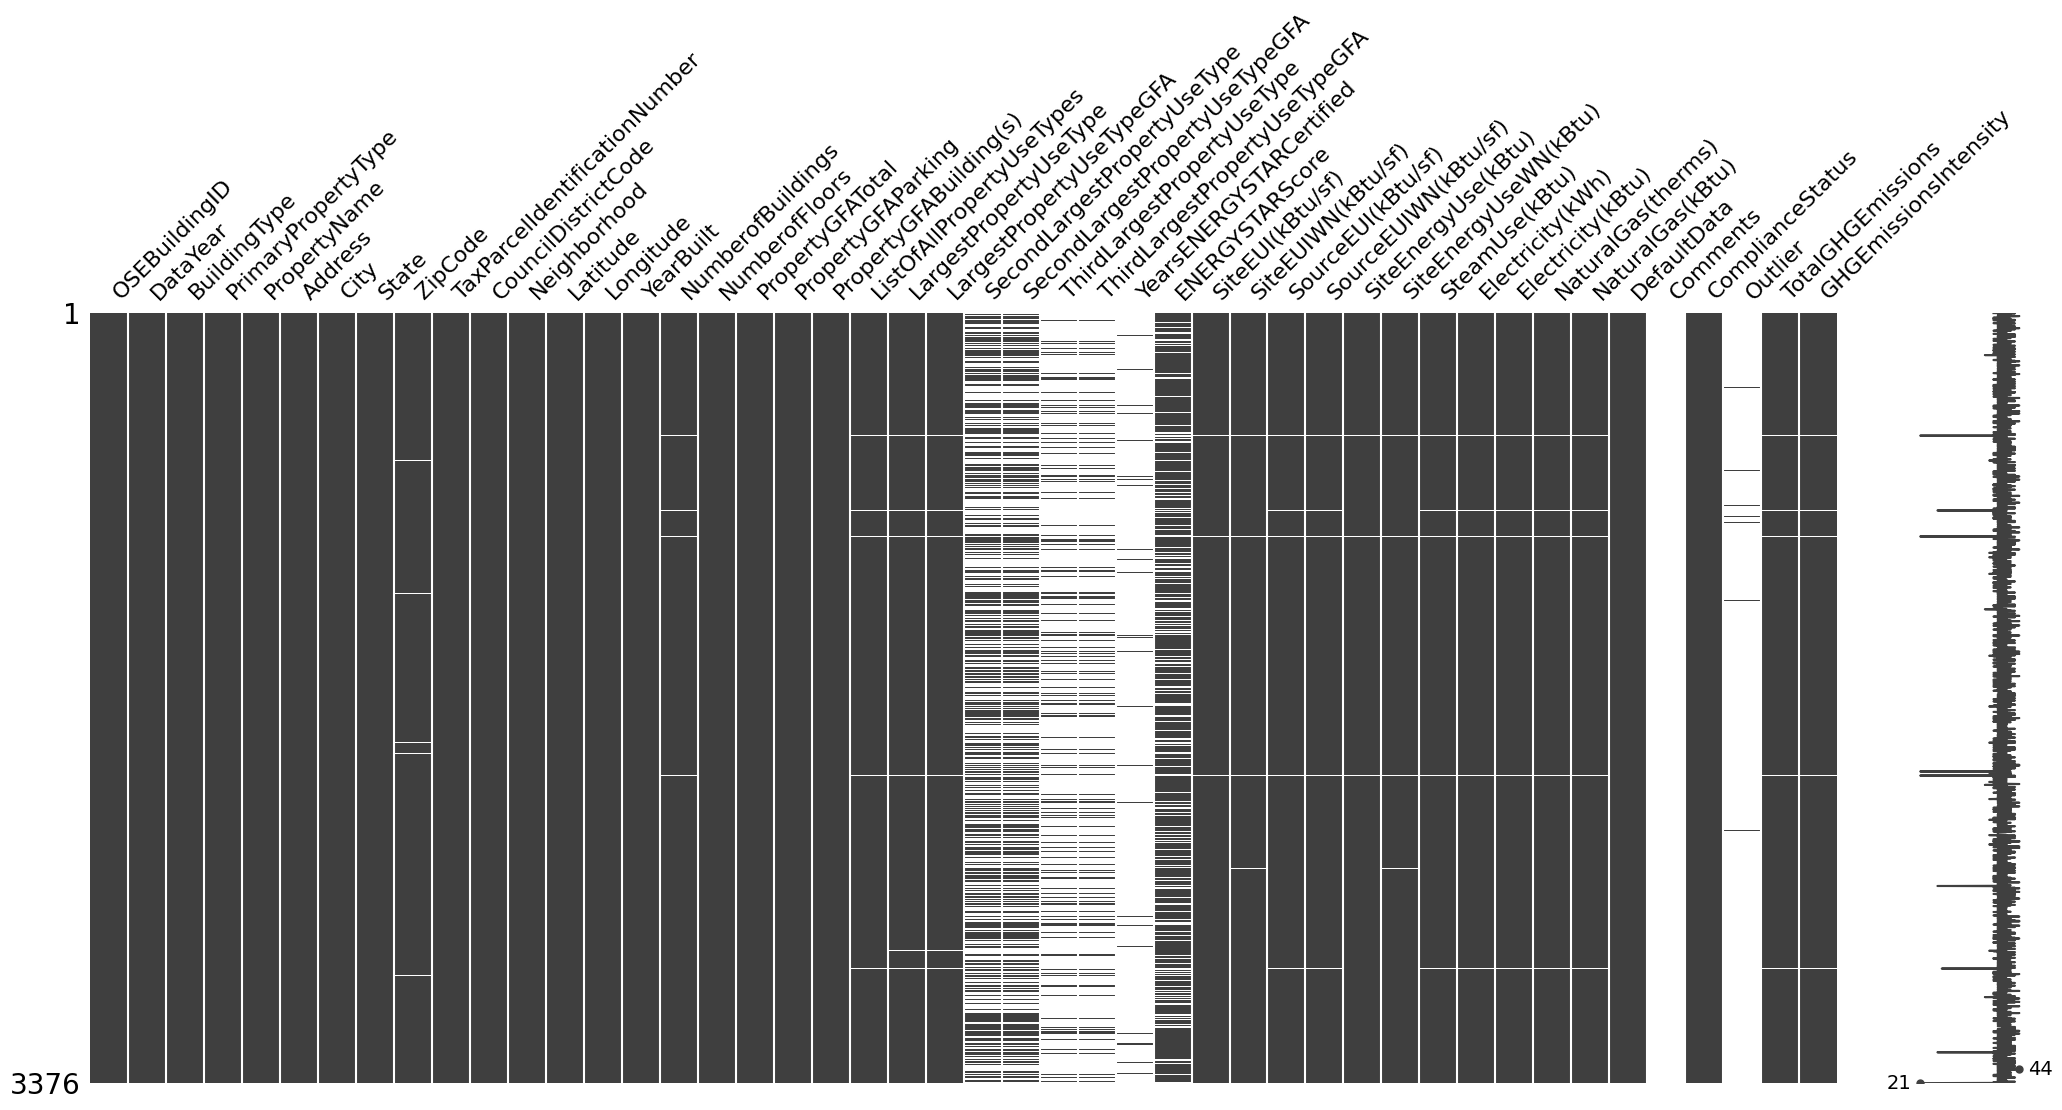

In [50]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
%matplotlib inline

# Afficher le type de chaque colonne
print("Types des colonnes :")
print(building_consumption.dtypes)

# Afficher la matrice de valeurs manquantes
nb_lines = building_consumption.shape[0]
msno.matrix(building_consumption.sample(nb_lines))

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

In [51]:
# Affiche tous les types de bâtiments
buildingtype_uniques = building_consumption['BuildingType'].unique()
df_uniques = pd.DataFrame(buildingtype_uniques, columns=['BuildingType'])
print(df_uniques)

           BuildingType
0        NonResidential
1    Nonresidential COS
2  Multifamily MR (5-9)
3     SPS-District K-12
4                Campus
5  Multifamily LR (1-4)
6  Multifamily HR (10+)
7     Nonresidential WA


In [52]:
# Afficher le nombre de lignes avant le filtre
print(f"Nombre de lignes avant le filtre : {len(building_consumption)}")

# Garder les lignes avec les bâtiments non destinés à l'habitation
# Liste des types de bâtiments non résidentiels
non_residentiel = [
    "NonResidential",
    "Nonresidential COS",
    "SPS-District K-12",
    "Campus",
    "Nonresidential WA"
]

# Filtrer le DataFrame
building_consumption_non_residentiel = building_consumption[
    building_consumption['BuildingType'].isin(non_residentiel)
]

# Afficher le nombre de lignes après le filtre
print(f"Nombre de lignes après le filtre : {len(building_consumption_non_residentiel)}")

Nombre de lignes avant le filtre : 3376
Nombre de lignes après le filtre : 1668


In [53]:
# Supprimer les bâtiments considérés comme des outliers
# Afficher le nombre de lignes avant le filtre
print(f"Nombre de lignes avant le filtre : {len(building_consumption_non_residentiel)}")

# Filtrer pour garder les lignes où 'Outlier' est vide ou NaN
building_consumption_sans_outliers = building_consumption_non_residentiel[
    building_consumption_non_residentiel['Outlier'].isna()
]

# Afficher le nombre de lignes après le filtre
print(f"Nombre de lignes après le filtre : {len(building_consumption_sans_outliers)}")

Nombre de lignes avant le filtre : 1668
Nombre de lignes après le filtre : 1651


In [54]:
# Supprimer les bâtiments avec des valeurs par défaut
# Afficher le nombre de lignes avant le filtre
print(f"Nombre de lignes avant le filtre : {len(building_consumption_sans_outliers)}")

# Filtrer pour garder les lignes où 'DefaultData' est "false"
building_consumption_without_defaultdata = building_consumption_sans_outliers[
    building_consumption_sans_outliers['DefaultData'] == "false"
]

# Afficher le nombre de lignes après le filtre
print(f"Nombre de lignes après le filtre : {len(building_consumption_without_defaultdata)}")

Nombre de lignes avant le filtre : 1651
Nombre de lignes après le filtre : 0


In [ ]:
# Garder les bâtiments conforme obligations réglementaires de reporting énergétique

In [ ]:
# Garder les colonnes pertinentes


# Modélisation 

### Import des modules 

In [ ]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [ ]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

In [ ]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [ ]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE